## Classic RLHF learns a reward model and then optimizes the policy with RL. DPO trains the policy directly from preferred vs rejected responses.

# Part 5 — Direct Preference Optimization (DPO)

At the end of Part 4, we had this classic RLHF pipeline:

Human Preferences

        ↓
Reward Model

        ↓
Reinforcement Learning

        ↓
Updated LLM

But this raises an interesting question:

> If humans have already told us which response they prefer,
> do we always need to build a separate Reward Model
> and then run Reinforcement Learning?

Maybe we can train directly from:

Preferred Response > Rejected Response

This idea leads to:

# Direct Preference Optimization

In [ ]:
### We know this 


#  We Already Have Preference Data

Suppose the prompt is:

> "Explain gravity to a 10-year-old."

The model produces:

### Response A

"Gravity is a manifestation of spacetime curvature
described by Einstein's field equations..."

### Response B

"Gravity is like an invisible pull that keeps your feet
on the ground and makes things fall toward Earth."

A human says:

# B > A

# Chosen and Rejected Responses

Preference datasets often represent responses as:

## Chosen Response

The response preferred by the human.

## Rejected Response

The alternative that was not preferred.

For our example:

Chosen:

"Gravity is like an invisible pull..."

Rejected:

"Gravity is a manifestation of spacetime curvature..."

In [ ]:
Prompt = x

Chosen response = y_w

Rejected response = y_l

In [ ]:
w = winner
l = loser

No need to overdo notation yet.

# Classic RLHF

Human says:

        B > A

But the LLM is not directly updated from that comparison.

Instead:

            B > A

              ↓
            Train Reward Model

              ↓
            Reward(B) > Reward(A)

              ↓
            Generate new responses

              ↓
            Reward Model scores them

              ↓
            PPO / RL

              ↓
            Update LLM

### The human comparison influences the LLM indirectly through the reward model and RL algorithm.

#  DPO - A DIRECT ROUTE

DPO takes a more direct route.

Human says:

B > A

Then training encourages the policy to make:

            B more likely

and

            A less likely

relative to a reference model.

Conceptually:

                            Prompt
                            
                               ↓
                            Chosen vs Rejected
                            
                               ↓
                            DPO Loss
                            
                               ↓
                            Update LLM

# CLASSIC RLHF

                        Preference
                           ↓
                        Reward Model
                           ↓
                        Reward
                           ↓
                        PPO
                           ↓
                        Policy



# DPO

                        Preference
                           ↓
                        DPO Objective
                           ↓
                        Policy

In [2]:
policy = {
    "chosen": 0.30,
    "rejected": 0.70
}

print("Current model preference:\n")

print(f"Chosen response  : {policy['chosen']:.0%}")
print(f"Rejected response: {policy['rejected']:.0%}")

Current model preference:

Chosen response  : 30%
Rejected response: 70%


In [ ]:
Ask:
“Is this consistent with the human preference?”

Lets say .......
No.

Humans chose the response that the model currently considers less likely.

In [ ]:
## Training needs to be done.... so it changes 

#  DPO Training Goal

Human preference:

Chosen > Rejected

Current policy:

Chosen   → 30%

Rejected → 70%

We want training to change the policy so that:

                Probability(Chosen)

becomes larger relative to

                Probability(Rejected).

## DPO is not trying to memorize one response. It changes model parameters so that preferred responses become more likely in similar contexts.

In [3]:
# just mimicing how it does internally

chosen_probability = 0.30
rejected_probability = 0.70

learning_rate = 0.1

for step in range(10):

    chosen_probability += learning_rate * (1 - chosen_probability)
    rejected_probability = 1 - chosen_probability

    print(
        f"Step {step+1:2} | "
        f"Chosen: {chosen_probability:.3f} | "
        f"Rejected: {rejected_probability:.3f}"
    )

Step  1 | Chosen: 0.370 | Rejected: 0.630
Step  2 | Chosen: 0.433 | Rejected: 0.567
Step  3 | Chosen: 0.490 | Rejected: 0.510
Step  4 | Chosen: 0.541 | Rejected: 0.459
Step  5 | Chosen: 0.587 | Rejected: 0.413
Step  6 | Chosen: 0.628 | Rejected: 0.372
Step  7 | Chosen: 0.665 | Rejected: 0.335
Step  8 | Chosen: 0.699 | Rejected: 0.301
Step  9 | Chosen: 0.729 | Rejected: 0.271
Step 10 | Chosen: 0.756 | Rejected: 0.244


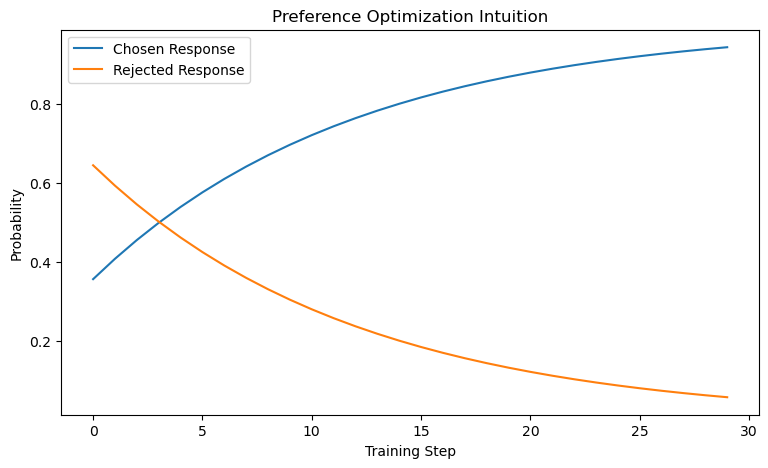

In [4]:
import matplotlib.pyplot as plt

chosen_history = []
rejected_history = []

chosen_probability = 0.30

for step in range(30):

    chosen_probability += 0.08 * (1 - chosen_probability)
    rejected_probability = 1 - chosen_probability

    chosen_history.append(chosen_probability)
    rejected_history.append(rejected_probability)


plt.figure(figsize=(9, 5))

plt.plot(chosen_history, label="Chosen Response")
plt.plot(rejected_history, label="Rejected Response")

plt.xlabel("Training Step")
plt.ylabel("Probability")
plt.title("Preference Optimization Intuition")

plt.legend()
plt.show()

# But do we need reference model ?

In [ ]:
#  The Reference Model Is Still Important

DPO does NOT simply say:

"Make the chosen response probability 100%."

We still want the model to remain reasonably close to
the behavior of the original SFT model.

So DPO compares:

## Current Policy

            πθ

with:

## Reference Policy

            πref

The reference model is usually a frozen copy of the model
before preference optimization.

#  What Does DPO Compare?

Suppose the policy becomes more likely to generate
the chosen response.

That is good.

But we also ask:

> "How much more likely is the chosen response under the
> new policy compared with the reference model?"

And:

> "What happened to the rejected response?"

DPO essentially learns from the **relative preference**
between these two responses.

In [6]:
# With respect to the reference model !!!!

policy_chosen = 0.60
reference_chosen = 0.30

policy_rejected = 0.20
reference_rejected = 0.50

chosen_ratio = policy_chosen / reference_chosen
rejected_ratio = policy_rejected / reference_rejected

print("Chosen ratio :", chosen_ratio)
print("Rejected ratio:", rejected_ratio)

Chosen ratio : 2.0
Rejected ratio: 0.4


## Compared with the reference model, the new policy has made the chosen response much more likely and the rejected response less likely.

#   Why Do We Often Use Log Probabilities?

Language models work with probabilities such as:

# P(response | prompt)

But full responses can contain many tokens.

Multiplying many probabilities produces extremely tiny numbers.

So machine-learning objectives often use:

# log P(response | prompt)

instead.


For understanding DPO, just remember:

# Higher log probability ≈ The model considers the response more likely.

#   DPO Objective — Conceptual Form

For a chosen response y_w and rejected response y_l,
DPO uses an objective involving:

# log πθ(y_w | x) - log πref(y_w | x)

and

# log πθ(y_l | x) - log πref(y_l | x)

The model is encouraged to make the chosen response
relatively more likely than the rejected response.

A commonly shown DPO preference term has the form:

σ(
β [
    log πθ(y_w | x)
    - log πref(y_w | x)
    - log πθ(y_l | x)
    + log πref(y_l | x)
]
)

where:

πθ   = current policy

πref = reference policy

y_w  = chosen response

y_l  = rejected response

β    = strength of the preference/reference trade-off

σ    = sigmoid

In [ ]:
#   Forget the Equation for a Moment

DPO is basically asking:

"Compared with the reference model, did the new policy become relatively more confident in the human-preferred response than in the rejected one?"

If yes:

            Good direction.

If not:

            Update the policy.

In [8]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))


log_policy_chosen = -0.5
log_reference_chosen = -1.0

log_policy_rejected = -1.8
log_reference_rejected = -1.2

beta = 0.5

preference_signal = beta * (
    (log_policy_chosen - log_reference_chosen)
    -
    (log_policy_rejected - log_reference_rejected)
)

probability = sigmoid(preference_signal)

print("Preference signal:", round(preference_signal, 3))
print("DPO preference probability:", round(probability, 3))

Preference signal: 0.55
DPO preference probability: 0.634


### When this value is high, the policy's relative probabilities are aligned with the preference pair.

In [12]:
# What happens if you increase the log probability of the chosen response? PLEASE TRY !

def dpo_preference(
    policy_chosen,
    ref_chosen,
    policy_rejected,
    ref_rejected,
    beta=1.0
):

    signal = beta * (
        (policy_chosen - ref_chosen)
        -
        (policy_rejected - ref_rejected)
    )

    return sigmoid(signal)


print(
    dpo_preference(
        policy_chosen=-0.2,
        ref_chosen=-1.0,
        policy_rejected=-2.0,
        ref_rejected=-1.0
    )
)

0.8581489350995123


#  Classic RLHF vs DPO

| Classic RLHF | DPO |
|---|---|
| Collect preference pairs | Collect preference pairs |
| Train Reward Model | No separate Reward Model required |
| Generate responses during RL | Train directly from preference examples |
| Reward Model scores outputs | Chosen vs rejected drive training |
| Use RL algorithm such as PPO | Use supervised-style optimization objective |
| Reference model commonly used | Reference model commonly used |
| More moving parts | Simpler training pipeline |

### Both are trying to use human preferences to improve the model. The training mechanism is different.

In [ ]:
#  Why Use DPO?

DPO can simplify preference optimization.

It avoids separately running:

                            Reward Model training
                            
                                        +
                            
                            Online RL / PPO optimization

Instead, preference pairs can be used directly to optimize the policy.

Potential practical advantages include:

- Simpler implementation
- Fewer moving parts
- No separate learned reward model during the DPO stage
- No PPO training loop
- Stable supervised-learning-style optimization

In [ ]:
#  Does DPO Replace RLHF Completely?

Not necessarily.

There are many approaches to post-training.

Different systems may use combinations of:

- SFT
- Reward Models
- Reinforcement Learning
- DPO
- Other preference-optimization methods
- AI-generated feedback
- Verifiable rewards
- Rule-based rewards

The best method depends on the task, available feedback, model scale, and training objectives.

In [ ]:
#  Question

In classic RLHF:

Human Preference
      ↓
Reward Model
      ↓
Reward
      ↓
Policy Update


In DPO:

Human Preference
      ↓
?????????
      ↓
Policy Update


What replaces the Reward Model + RL loop?

In [ ]:
# THINK !

Human preference:

Response B > Response A

Current Policy:

    P(B) = 0.25
    
    P(A) = 0.60

Reference Model:

        P(B) = 0.20
        
        P(A) = 0.50


### QUESTION

1. Which response is chosen?
2. Which response is rejected?
3. Which response should become relatively more likely?
4. Does DPO require us to first convert B > A into a
   numerical human reward such as 8.7?
5. Is the reference model still useful?

#  Online vs Offline Preference Learning

Classic PPO-based RLHF commonly includes an **online**
generation loop:

                    Current Policy
                          ↓
                    Generate new responses
                          ↓
                    Reward Model evaluates them
                          ↓
                    Update Policy
                          ↓
                    Generate again
                    

DPO can be trained from a fixed preference dataset:

                    Prompt
                       + 
                    Chosen Response & Rejected Response
                    
                          ↓
                    
                    Optimize

In [13]:
preference_dataset = [
    {
        "prompt": "Explain gravity to a child.",
        "chosen": "Gravity is like an invisible pull that keeps us on Earth.",
        "rejected": "Gravity is described by spacetime curvature tensors."
    },

    {
        "prompt": "What is machine learning?",
        "chosen": "Machine learning lets computers learn patterns from examples.",
        "rejected": "Machine learning is a computational paradigm."
    },

    {
        "prompt": "Explain the Moon to a child.",
        "chosen": "The Moon is a rocky world that travels around Earth.",
        "rejected": "The Moon has a mean radius of approximately 1,737 kilometers."
    }
]

for example in preference_dataset:

    print("\nPROMPT:")
    print(example["prompt"])

    print("\nCHOSEN:")
    print(example["chosen"])

    print("\nREJECTED:")
    print(example["rejected"])

    print("-" * 60)


PROMPT:
Explain gravity to a child.

CHOSEN:
Gravity is like an invisible pull that keeps us on Earth.

REJECTED:
Gravity is described by spacetime curvature tensors.
------------------------------------------------------------

PROMPT:
What is machine learning?

CHOSEN:
Machine learning lets computers learn patterns from examples.

REJECTED:
Machine learning is a computational paradigm.
------------------------------------------------------------

PROMPT:
Explain the Moon to a child.

CHOSEN:
The Moon is a rocky world that travels around Earth.

REJECTED:
The Moon has a mean radius of approximately 1,737 kilometers.
------------------------------------------------------------


#  The Model Learns From the Preferences We Give It

Suppose humans consistently prefer:

        Very long answers

        over

                Concise answers.

Then preference optimization may teach the model:

> Longer answers are better.

    Suppose annotators have inconsistent judgments.

Then the training signal becomes noisy.

Therefore:

# Feedback quality matters.

Preference optimization does not magically know
"true human values."

It learns patterns represented in the preference data.

#   Preference Optimization Is a Bigger Family

We started with:

## Classic RLHF

Preference Data
→ Reward Model
→ PPO


Then learned:

## DPO

Preference Data
→ Direct Preference Objective


DPO is one member of a broader family of methods
for training language models from preference data.

The important concept is larger than any individual algorithm:

> **Use preference information to change model behavior.**

#   Complete Story So Far

## 1. Pretraining

Text
→ Next-token prediction
→ Base LLM


## 2. Supervised Fine-Tuning

Instruction + Good Response
→ Instruction-following model


## 3. Human Preference Collection

Response A vs Response B
→ Human chooses one


## 4A. Classic RLHF

Preferences
→ Reward Model
→ Reward
→ PPO / RL
→ Updated LLM


## 4B. DPO

Preferences
→ Chosen vs Rejected
→ DPO Objective
→ Updated LLM

#  Can You Identify the Training Signal?

### Pretraining

What tells the model it was wrong?


### SFT

What tells the model what response to produce?


### Reward Model Training

What tells the model which response should score higher?


### PPO-Based RLHF

What tells the policy whether a response was good?


### DPO

What tells the policy which direction to move?

#   Each Stage in One Sentence

### Pretraining

Learn to predict language.


### SFT

Learn to follow instructions from demonstrations.


### RLHF

Learn behavior using rewards derived from human preferences.


### DPO

Learn directly from which responses humans prefer.

In [ ]:
                      RAW TEXT
                         │
                         ▼
                   PRETRAINING
                         │
                         ▼
                     BASE LLM
                         │
                         ▼
                        SFT
                         │
                         ▼
               INSTRUCTION MODEL
                         │
                         ▼
                HUMAN PREFERENCES
                         │
                ┌────────┴─────────┐
                │                  │
                ▼                  ▼
         CLASSIC RLHF             DPO
                │                  │
        Reward Model       Chosen / Rejected
                │                  │
              PPO             DPO Objective
                │                  │
                └────────┬─────────┘
                         ▼
                 POST-TRAINED LLM

# Assignment

#  Final Challenge

You are given:

Prompt:

"Explain quantum computing to a beginner."

Response A:

"Quantum computers use quantum bits and properties such
as superposition to solve certain kinds of problems
differently from ordinary computers."

Response B:

"A quantum computational architecture utilizes Hilbert-space
representations of unitary transformations."

A human chooses:

A > B


### Explain what happens next using:

1. Classic RLHF

and

2. DPO

In [ ]:
#   Assignment 2

You should be able to explain:

What Reinforcement Learning is
What a Policy is
Where Rewards come from in RLHF
How humans provide preference data
Why a Reward Model is trained
How RL changes an LLM policy
Why a Reference Model and KL penalty are useful
Where PPO fits into classic RLHF
Where RLHF fits in the full LLM training pipeline
How DPO differs from classic RLHF

Most importantly:

# RLHF is about turning human preferences into
# a training signal that changes model behavior.